In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
mount_path = '/content/drive/'
drive.mount(mount_path)

file_path = mount_path + 'My Drive/Colab Notebooks/salario_profissionais_dados.csv'
file_path_excel = mount_path + 'My Drive/Colab Notebooks/salario_profissionais_dados.xlsx'

leitura_csv = pd.read_csv(file_path)
print("\nLeitura CSV: \n", leitura_csv)

leitura_csv_tratado = pd.read_csv(file_path, sep=',', quotechar='"', engine='python')
print("\nLeitura CSV tratado: \n", leitura_csv_tratado)

leitura_excel = pd.read_excel(file_path_excel)
print("\nLeitura Excel: \n", leitura_excel)

df = pd.DataFrame(leitura_excel)
print("\nDataframe do CSV: \n", df)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).

Leitura CSV: 
      work_year                   country    region experience_level  \
0         2023                     Spain    Europe               SE   
1         2023  United States of America  Americas               MI   
2         2023  United States of America  Americas               MI   
3         2023                    Canada  Americas               SE   
4         2023                    Canada  Americas               SE   
...        ...                       ...       ...              ...   
3750      2020  United States of America  Americas               SE   
3751      2021  United States of America  Americas               MI   
3752      2020  United States of America  Americas               EN   
3753      2020  United States of America  Americas               EN   
3754      2021                     India      Asia               SE   



In [ ]:
# Etapa 01) Importação e Exploração Inicial da Base
# - Existem dados ausentes?
# Traz as primeiras linhas da tabela
print(df.head())


  work_year                   country    region experience_level  \
0      2023                     Spain    Europe               SE   
1      2023  United States of America  Americas               MI   
2      2023  United States of America  Americas               MI   
3      2023                    Canada  Americas               SE   
4      2023                    Canada  Americas               SE   

                  job_title  salary_in_usd employee_residence  \
0  Principal Data Scientist        85847.0                 ES   
1               ML Engineer        30000.0                 US   
2               ML Engineer        25500.0                 US   
3            Data Scientist       175000.0                 CA   
4            Data Scientist       120000.0                 CA   

  company_location company_size  years_of_experience  
0               ES            L                  8.0  
1               US            S                  5.0  
2               US            S    

In [ ]:
# mostra a quantidade de linhas e colunas
print("\nFormato (linhas, colunas):")
print(df.shape)



Formato (linhas, colunas):
(3755, 10)


In [ ]:
# Mostra informações do dataframe: colunas, linhas, tipos das colunas e etc.
# - Quais colunas estão disponíveis? 10 colunas
print("\nColunas disponíveis: ")
print(df.columns)

# - Quais são os tipos de variáveis? float64 e object
print("\nInformações sobre colunas:")
print(df.info())



Colunas disponíveis: 
Index(['work_year', 'country', 'region', 'experience_level', 'job_title',
       'salary_in_usd', 'employee_residence', 'company_location',
       'company_size', 'years_of_experience'],
      dtype='object')

Informações sobre colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   work_year            3755 non-null   object 
 1   country              3735 non-null   object 
 2   region               3735 non-null   object 
 3   experience_level     3735 non-null   object 
 4   job_title            3735 non-null   object 
 5   salary_in_usd        3735 non-null   float64
 6   employee_residence   3735 non-null   object 
 7   company_location     3735 non-null   object 
 8   company_size         3735 non-null   object 
 9   years_of_experience  3735 non-null   float64
dtypes: float64(2), object(8)
mem

In [ ]:
# mostra a quantidade de dados ausentes em cada coluna
print("\nValores ausentes por coluna: ")
print(df.isnull().sum())


Valores ausentes por coluna: 
work_year               0
country                20
region                 20
experience_level       20
job_title              20
salary_in_usd          20
employee_residence     20
company_location       20
company_size           20
years_of_experience    20
dtype: int64


In [ ]:
# Etapa 02) Frequência e Distribuição das Categorias
# - Cargos mais comuns
print("\nCargos mais comuns")
print(df.groupby('job_title').value_counts(normalize=True))

# - Nível de experiência
print("\nNível de experiência")
print(df.groupby('experience_level').value_counts(normalize=True))

# - Tamanho da empresa
print("\nTamanho da empresa")
print(df.groupby('company_size').value_counts(normalize=True))



Cargos mais comuns
job_title                      work_year  country                   region    experience_level  salary_in_usd  employee_residence  company_location  company_size  years_of_experience
3D Computer Vision Researcher  2021       American Samoa            Oceania   EN                20000.0        AS                  AS                M             2.0                    0.250000
                                          India                     Asia      MI                5409.0         IN                  IN                M             4.0                    0.250000
                               2022       Canada                    Americas  SE                10000.0        CA                  AL                S             7.0                    0.250000
                                          United States of America  Americas  EN                50000.0        US                  CR                S             1.0                    0.250000
AI Developer     


Estatísticas descritivas dos salários:
count      3735.000000
mean     137922.104953
std       63001.932966
min        5132.000000
25%       95000.000000
50%      135000.000000
75%      175000.000000
max      450000.000000
Name: salary_in_usd, dtype: float64


MEDIANA

Mediana de salário por cargo: 
job_title
3D Computer Vision Researcher     15000.0
AI Developer                     108000.0
AI Programmer                     55000.0
AI Scientist                      52500.0
Analytics Engineer               146930.0
                                   ...   
Research Engineer                155000.0
Research Scientist               150000.0
Software Data Engineer            62510.0
Staff Data Analyst                15000.0
Staff Data Scientist             105000.0
Name: salary_in_usd, Length: 92, dtype: float64

Mediana de salário por tamanho da empresa: 
company_size
L    110000.0
M    140000.0
S     62726.0
Name: salary_in_usd, dtype: float64

Mediana de salário por nível de experiênc

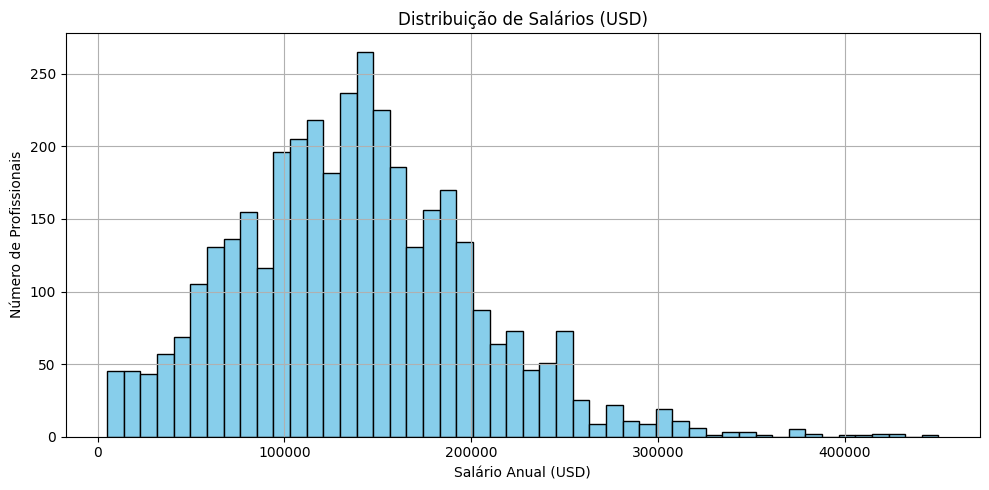


Boxplot do salário por nível de experiência:


/tmp/ipython-input-10-1479619306.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='experience_level', y='salary_in_usd', palette='Set2')


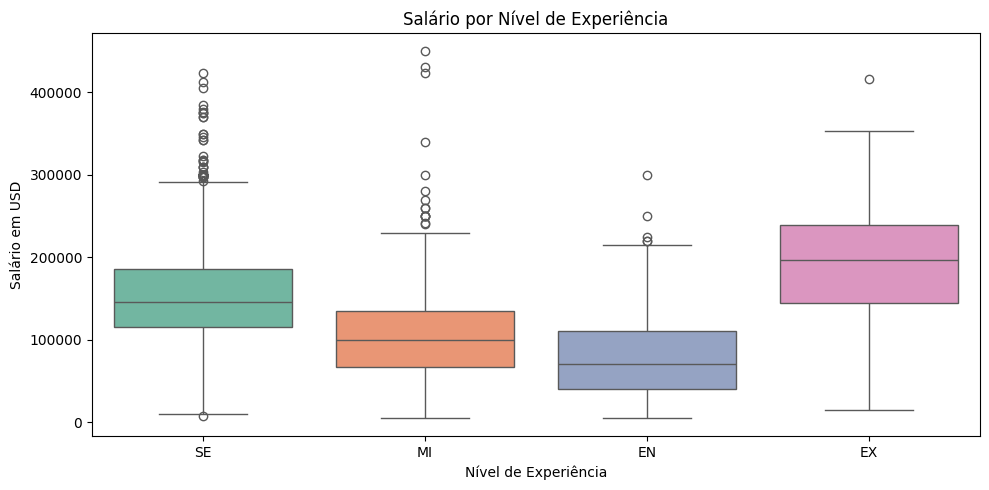

In [ ]:
# Etapa 03) Estatísticas Descritivas
# Medidas de tendência central: média, mediana
# Medidas de dispersão: desvio padrão, mínimo e máximo
# **Distribuição geral:** através de histogramas
# **Comparações por grupos:** especialmente por nível de experiência (usando boxplots)
print("\nEstatísticas descritivas dos salários:")
print(df['salary_in_usd'].describe())
print("\n")

print("MEDIANA")
print("\nMediana de salário por cargo: ")
print(df.groupby('job_title')['salary_in_usd'].median())
print("\nMediana de salário por tamanho da empresa: ")
print(df.groupby('company_size')['salary_in_usd'].median())
print("\nMediana de salário por nível de experiência: ")
print(df.groupby('experience_level')['salary_in_usd'].median())
print("\n")

print("MÉDIA")
print("\nMédia de salário por cargo: ")
print(df.groupby('job_title')['salary_in_usd'].mean())
print("\nMédia de salário entre categorias: ")
print(df.groupby('company_size')['salary_in_usd'].mean())
print("\nMédia de salário por nível de experiência: ")
print(df.groupby('experience_level')['salary_in_usd'].mean())
print("\n")

# Desvio padrão
print("\nDesvio padrão do salário:")
print(df['salary_in_usd'].std())

# Mínimo e máximo
print("\nMínimo e máximo do salário:")
print(df['salary_in_usd'].min())
print(df['salary_in_usd'].max())

# Distribuição Geral em Histograma
# print(df['salary_in_usd'].plot.hist(bins=50, figsize=(10, 5), title='Distribuição de Salários (USD)'))
# Histograma
print("\nHistograma do salário:")
plt.figure(figsize=(10, 5))
plt.hist(df['salary_in_usd'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribuição de Salários (USD)')
plt.xlabel('Salário Anual (USD)')
plt.ylabel('Número de Profissionais')
plt.grid(True)
plt.tight_layout()
plt.show()

# Comparação por Grupo - Nível de Experiência
# Boxplot
print("\nBoxplot do salário por nível de experiência:")
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='experience_level', y='salary_in_usd', palette='Set2')
plt.title('Salário por Nível de Experiência')
plt.xlabel('Nível de Experiência')
plt.ylabel('Salário em USD')
plt.tight_layout()
plt.show()





🌍 Top 10 países com maiores salários médios:
employee_residence
IL    423834.000000
MY    200000.000000
PR    166000.000000
US    152822.011651
CA    132222.905882
CN    125404.000000
NZ    125000.000000
BA    120000.000000
IE    114943.428571
DO    110000.000000
Name: salary_in_usd, dtype: float64


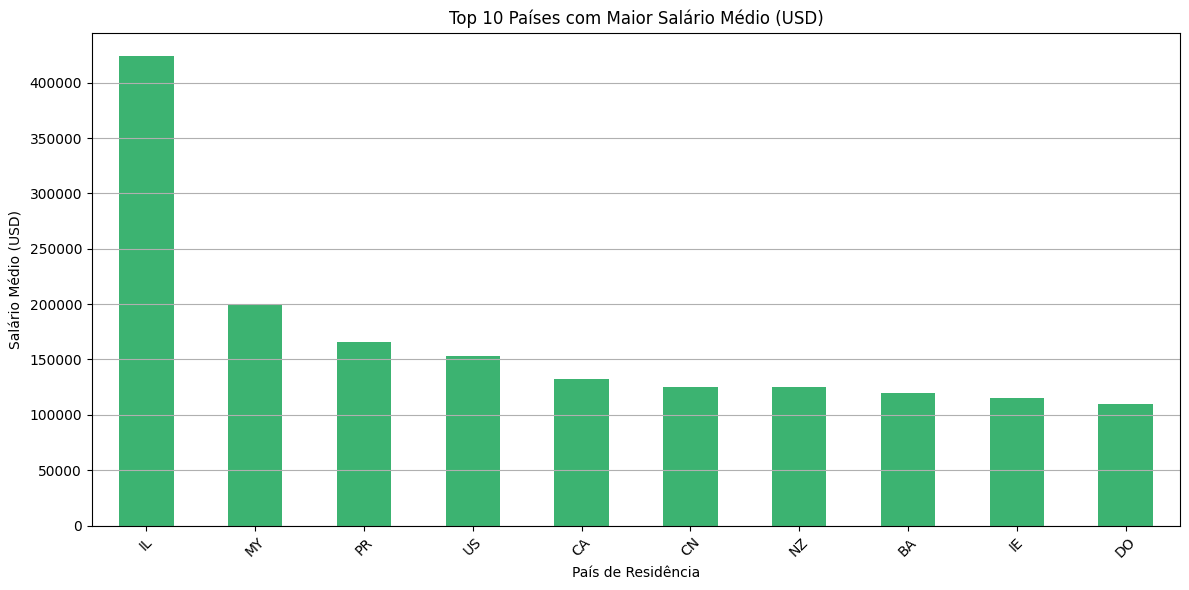

In [ ]:
## **Etapa 04)  Comparações por País**
# Agora que você já entendeu os salários em geral, é hora de investigar **como eles variam entre diferentes grupos**.
# Nesta etapa, seu objetivo será:
# - Verificar os **10 países** com as maiores médias salariais
# Essas comparações são fundamentais para entender onde estão os maiores salários — seja em termos de função ou localização geográfica.

# =============================
# 🔹 Etapa 04 – Comparações por País
# =============================

# Salário médio por país
salario_por_pais = df.groupby('employee_residence')['salary_in_usd'].mean().sort_values(ascending=False)

print("\n🌍 Top 10 países com maiores salários médios:")
print(salario_por_pais.head(10))

# Gráfico de barras
plt.figure(figsize=(12, 6))
salario_por_pais.head(10).plot(kind='bar', color='mediumseagreen')
plt.title('Top 10 Países com Maior Salário Médio (USD)')
plt.ylabel('Salário Médio (USD)')
plt.xlabel('País de Residência')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


📆 Média salarial por ano:
work_year
2020     92302.631579
2021     94087.208696
2022    133338.620793
2023    149045.541176
Name: salary_in_usd, dtype: float64


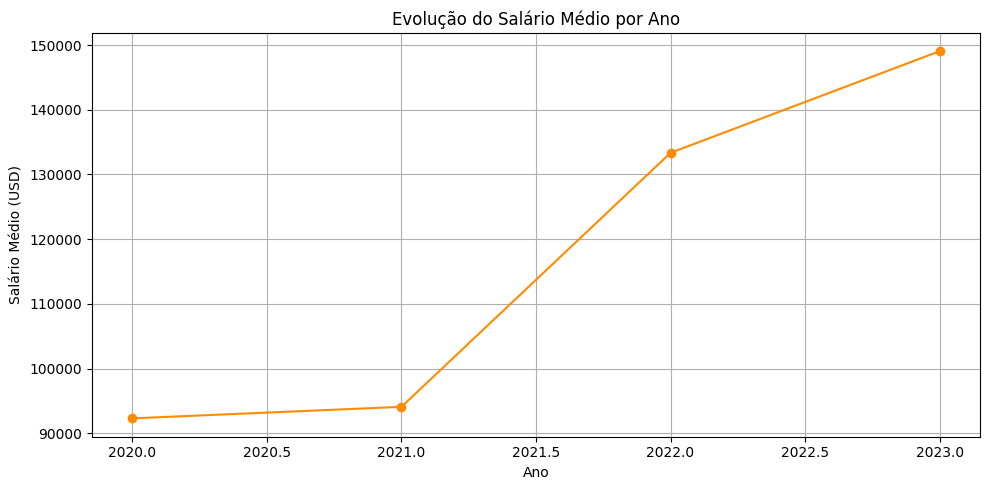


🔗 Matriz de Correlação:
                     salary_in_usd  work_year  years_of_experience
salary_in_usd             1.000000   0.228290             0.410723
work_year                 0.228290   1.000000             0.178878
years_of_experience       0.410723   0.178878             1.000000


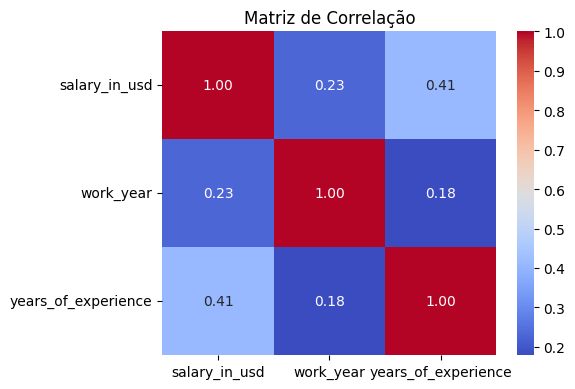

In [ ]:
## **Etapa 05) Correlações e Tendências**
# Por fim, vamos analisar se existe alguma relação entre salário e outras variáveis **quantitativas** da base.
# As perguntas principais aqui são:
# - Existe alguma **tendência de aumento salarial com os anos?**
# - Quanto maior o tempo de experiência, maior o salário?
# Você irá utilizar uma **matriz de correlação** para investigar essas relações e interpretar os coeficientes gerados.

# =============================
# 🔹 Etapa 05 – Correlações e Tendências
# =============================

# Salário médio por ano
media_salarial_por_ano = df.groupby('work_year')['salary_in_usd'].mean()
print("\n📆 Média salarial por ano:")
print(media_salarial_por_ano)

# Gráfico de tendência ao longo dos anos
plt.figure(figsize=(10, 5))
media_salarial_por_ano.plot(marker='o', color='darkorange')
plt.title('Evolução do Salário Médio por Ano')
plt.xlabel('Ano')
plt.ylabel('Salário Médio (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Correlação entre variáveis numéricas
correlacoes = df[['salary_in_usd', 'work_year', 'years_of_experience']].corr()
print("\n🔗 Matriz de Correlação:")
print(correlacoes)

# Heatmap da correlação
plt.figure(figsize=(6, 4))
sns.heatmap(correlacoes, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()